# OIBSIP Task 2
# Unemployment Analysis with Python

Author: Muhammad Danish

Internship: Oasis Infobyte Data Science

In [1]:
# Import required libraries for data analysis and visualization
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#Data Loading

In [2]:
# Load unemployment dataset into a pandas DataFrame
df = pd.read_csv("Unemployment_Rate_upto_11_2020.csv")

# Display first 5 rows
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Region.1,longitude,latitude
0,Andhra Pradesh,31-01-2020,M,5.48,16635535,41.02,South,15.9129,79.74
1,Andhra Pradesh,29-02-2020,M,5.83,16545652,40.90,South,15.9129,79.74
2,Andhra Pradesh,31-03-2020,M,5.79,15881197,39.18,South,15.9129,79.74
3,Andhra Pradesh,30-04-2020,M,20.51,11336911,33.10,South,15.9129,79.74
4,Andhra Pradesh,31-05-2020,M,17.43,12988845,36.46,South,15.9129,79.74


In [3]:
# display last 5 rows
df.tail(5)

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Region.1,longitude,latitude
262,West Bengal,30-06-2020,M,7.29,30726310,40.39,East,22.9868,87.855
263,West Bengal,31-07-2020,M,6.83,35372506,46.17,East,22.9868,87.855
264,West Bengal,31-08-2020,M,14.87,33298644,47.48,East,22.9868,87.855
265,West Bengal,30-09-2020,M,9.35,35707239,47.73,East,22.9868,87.855
266,West Bengal,31-10-2020,M,9.98,33962549,45.63,East,22.9868,87.855


#Dataset Inspection

In [4]:
# Check number of rows and columns
print("Dataset Shape:", df.shape)

# Display information about columns and data types
df.info()

# Check for missing values
print(df.isnull().sum())

Dataset Shape: (267, 9)
<class 'pandas.DataFrame'>
RangeIndex: 267 entries, 0 to 266
Data columns (total 9 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    267 non-null    str    
 1    Date                                     267 non-null    str    
 2    Frequency                                267 non-null    str    
 3    Estimated Unemployment Rate (%)          267 non-null    float64
 4    Estimated Employed                       267 non-null    int64  
 5    Estimated Labour Participation Rate (%)  267 non-null    float64
 6   Region.1                                  267 non-null    str    
 7   longitude                                 267 non-null    float64
 8   latitude                                  267 non-null    float64
dtypes: float64(4), int64(1), str(4)
memory usage: 18.9 KB
Region                                     

#Data Cleaning

In [7]:
# Remove extra spaces from column names
df.columns = df.columns.str.strip()

# Convert Date column from string to datetime format (DD-MM-YYYY)
df['Date'] = pd.to_datetime(
    df['Date'],
    dayfirst=True
)

# Verify updated data types
print(df.dtypes)

Region                                                str
Date                                       datetime64[us]
Frequency                                             str
Estimated Unemployment Rate (%)                   float64
Estimated Employed                                  int64
Estimated Labour Participation Rate (%)           float64
Region.1                                              str
longitude                                         float64
latitude                                          float64
dtype: object


#Region-wise Average Unemployment

In [8]:
# Calculate average unemployment rate for each state/region
region_avg = (
    df.groupby('Region')
    ['Estimated Unemployment Rate (%)']
    .mean()
    .sort_values(ascending=False)
)

# Display results
display(region_avg.head())

Region
Haryana      27.477
Tripura      25.055
Jharkhand    19.539
Bihar        19.471
Delhi        18.414
Name: Estimated Unemployment Rate (%), dtype: float64

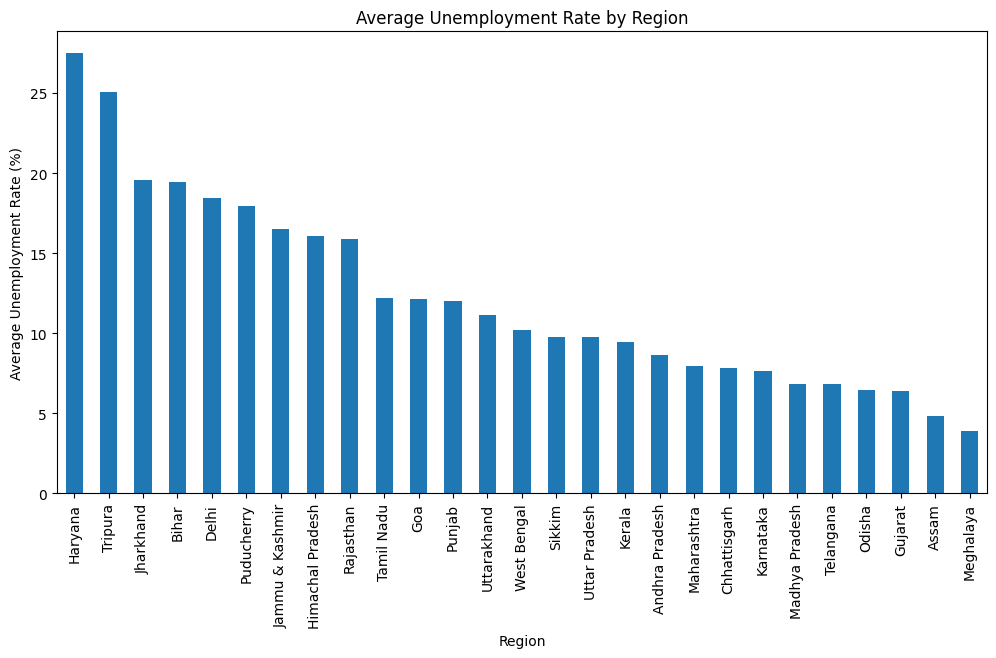

In [10]:
# Plot average unemployment rate by region
plt.figure(figsize=(12,6))

region_avg.plot(kind='bar')

plt.title("Average Unemployment Rate by Region")
plt.xlabel("Region")
plt.ylabel("Average Unemployment Rate (%)")

plt.savefig(
    "outputs/region_wise_analysis.png",
    bbox_inches='tight'
)

plt.show()

### Observation

The graph shows noticeable differences in unemployment rates across regions. Some states consistently experience higher unemployment levels than others, indicating unequal employment opportunities and economic development across India.

#Month-wise Trend Analysis

In [12]:
# Calculate average unemployment rate for each month
monthly_avg = (
    df.groupby('Date')
    ['Estimated Unemployment Rate (%)']
    .mean()
)

display(monthly_avg.head(10))

Date
2020-01-31     9.196538
2020-02-29     9.266154
2020-03-31    10.782593
2020-04-30    22.236154
2020-05-31    23.244444
2020-06-30    10.911111
2020-07-31     9.834444
2020-08-31    10.313333
2020-09-30     8.705926
2020-10-31     8.026296
Name: Estimated Unemployment Rate (%), dtype: float64

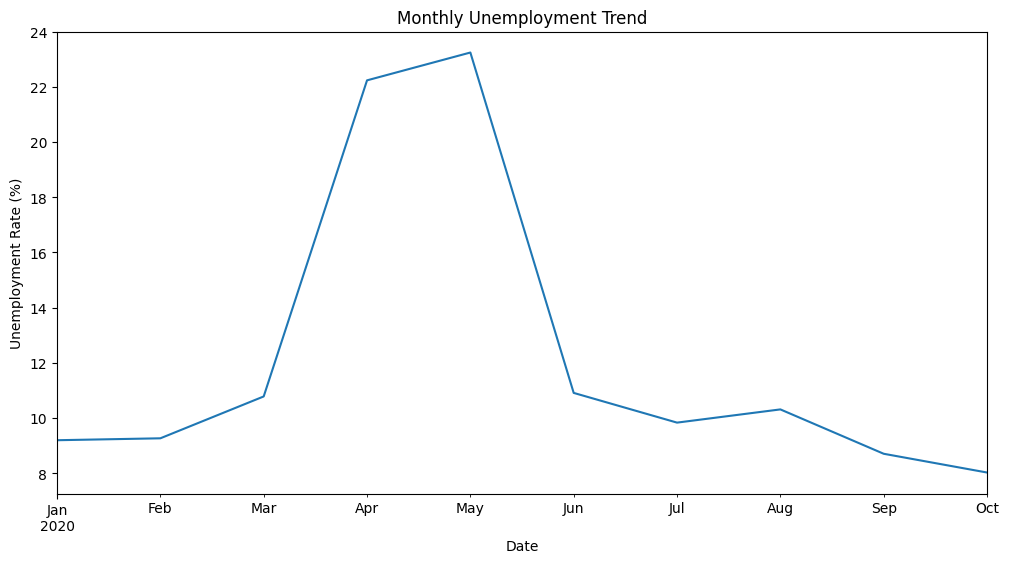

In [13]:
# Create line chart to observe unemployment trend over time
plt.figure(figsize=(12,6))

monthly_avg.plot()

plt.title("Monthly Unemployment Trend")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")

plt.savefig(
    "outputs/monthly_unemployment_trend.png",
    bbox_inches='tight'
)

plt.show()

### Observation

The unemployment rate fluctuates over time rather than remaining constant. A sharp rise can be observed during the COVID-19 period like april and may, followed by a gradual decline as economic activities resumed.

#Time Series Analysis of Major States

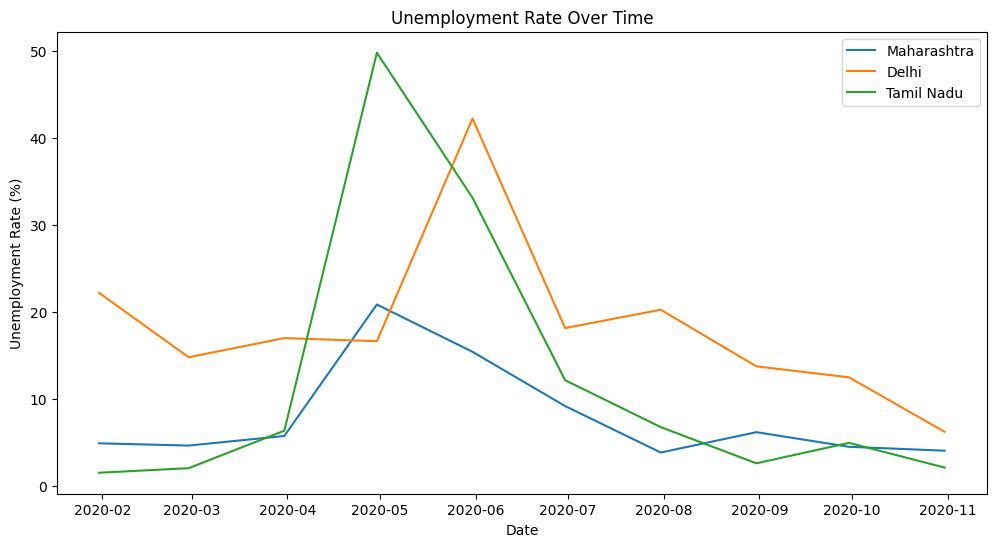

In [15]:
# Select three major states for comparison
states = [
    'Maharashtra',
    'Delhi',
    'Tamil Nadu'
]

plt.figure(figsize=(12,6))

# Plot unemployment trend for each selected state
for state in states:

    state_data = df[df['Region'] == state]

    plt.plot(
        state_data['Date'],
        state_data['Estimated Unemployment Rate (%)'],
        label=state
    )

plt.title("Unemployment Rate Over Time")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")
plt.legend()

plt.savefig(
    "outputs/trend_comparison.png",
    bbox_inches='tight'
)

plt.show()

### Observation

The selected states display different unemployment patterns throughout the study period. Although all states were affected by the pandemic, the severity and recovery rates varied from one state to another.

#Top 10 States with Highest Unemployment

In [17]:
# Calculate average unemployment rate and select top 10 states
top10 = (
    df.groupby('Region')
    ['Estimated Unemployment Rate (%)']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

display(top10)

Region
Haryana             27.477000
Tripura             25.055000
Jharkhand           19.539000
Bihar               19.471000
Delhi               18.414000
Puducherry          17.942000
Jammu & Kashmir     16.477778
Himachal Pradesh    16.065000
Rajasthan           15.868000
Tamil Nadu          12.187000
Name: Estimated Unemployment Rate (%), dtype: float64

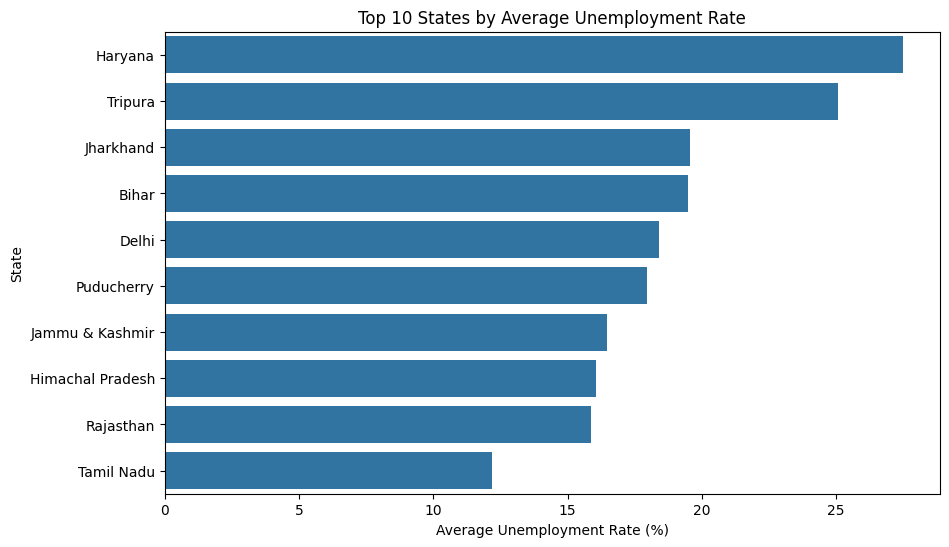

In [18]:
# Visualize top 10 states using a bar chart
plt.figure(figsize=(10,6))

sns.barplot(
    x=top10.values,
    y=top10.index
)

plt.title("Top 10 States by Average Unemployment Rate")
plt.xlabel("Average Unemployment Rate (%)")
plt.ylabel("State")

plt.savefig(
    "outputs/top10_states.png",
    bbox_inches='tight'
)

plt.show()

### Observation

The chart highlights the states with the highest average unemployment rates. These regions may face greater employment challenges and could require stronger policy interventions to improve job opportunities.

#Correlation Heatmap

In [19]:
# Select numerical columns for correlation analysis
corr_data = df[
[
    'Estimated Unemployment Rate (%)',
    'Estimated Employed',
    'Estimated Labour Participation Rate (%)'
]
]

# Compute correlation matrix
corr_matrix = corr_data.corr()

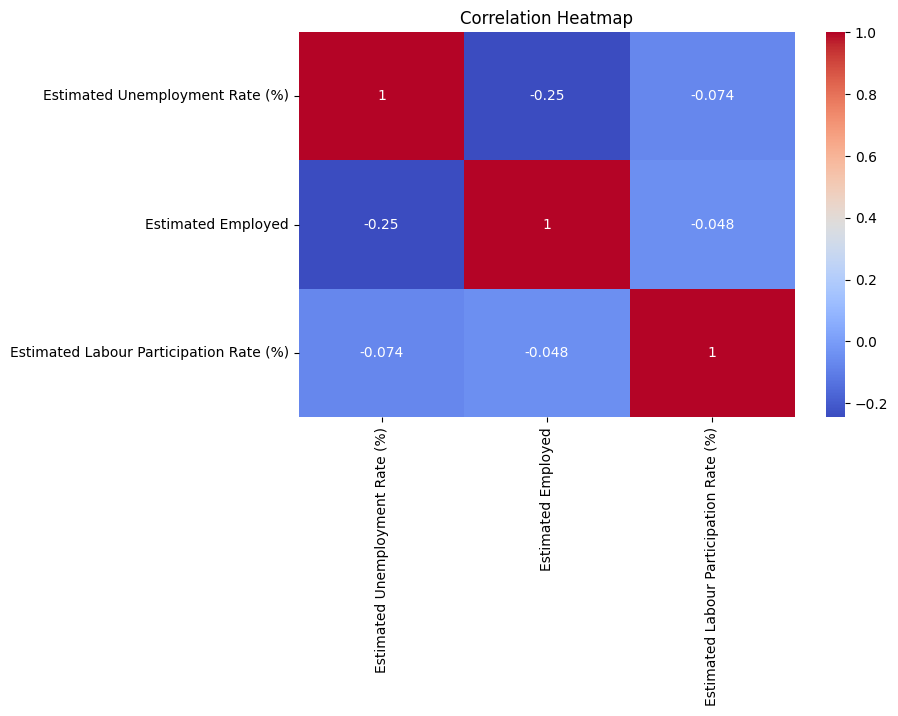

In [20]:
# Create heatmap to visualize relationships among variables
plt.figure(figsize=(8,5))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.savefig(
    "outputs/correlation_heatmap.png",
    bbox_inches='tight'
)

plt.show()

### Observation

The heatmap illustrates the relationships among unemployment rate, employment level, and labour participation rate. Positive and negative correlations indicate how changes in one variable may be associated with changes in another.

#Pre-COVID vs Post-COVID Analysis

In [21]:
# Define COVID-19 starting period for comparison
covid_date = '2020-03-01'

# Separate data before and after COVID outbreak
pre_covid = df[df['Date'] < covid_date]
post_covid = df[df['Date'] >= covid_date]

# Calculate average unemployment rate for both periods
pre_mean = pre_covid[
    'Estimated Unemployment Rate (%)'
].mean()

post_mean = post_covid[
    'Estimated Unemployment Rate (%)'
].mean()

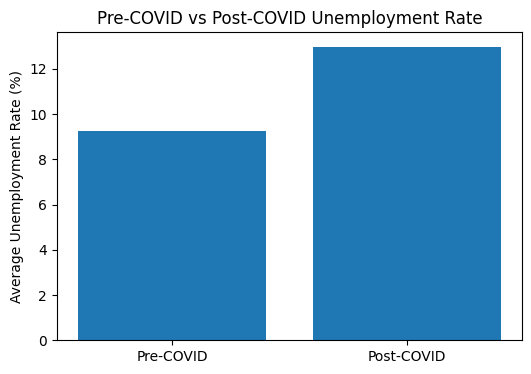

In [22]:
# Compare average unemployment rates using a bar chart
plt.figure(figsize=(6,4))

plt.bar(
    ['Pre-COVID', 'Post-COVID'],
    [pre_mean, post_mean]
)

plt.title("Pre-COVID vs Post-COVID Unemployment Rate")
plt.ylabel("Average Unemployment Rate (%)")

plt.savefig(
    "outputs/pre_post_covid_comparison.png",
    bbox_inches='tight'
)

plt.show()

### Observation

The average unemployment rate increased significantly after the onset of COVID-19. This suggests that lockdowns and economic disruptions had a substantial impact on employment across the country.

## Conclusion

- Unemployment rates vary significantly across Indian states.
- Several regions consistently show higher unemployment than others.
- The COVID-19 pandemic caused a sharp increase in unemployment levels.
- Time-series analysis revealed noticeable spikes during lockdown periods.
- Correlation analysis helped identify relationships between unemployment, employment, and labour participation rates.